In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import acf

OUTPUT_DIR  = Path("../outputs")

# Diagnostics

This notebook loads the raw outputs produced by main.py and evaluates the quality of the Gibbs sampler chain.
It does NOT run the model — run main.py first, then open this.

What it is checked:
   - whether the chain has mixed and converged (trace plots, ESS)
   - whether individual edges are well-identified (autocorrelation)
   - the posterior distribution of each Gibbs check (inclusion probs, MAP graph)

Sections are ordered by Gibbs step.

### Functions used for checks:
1. **Trace plot**: it plots a scalar quantity over post-burnin iterations. It is used to check *stationarity*: the series should fluctuate around a stable mean with no visible trend. 

2. **ACF grid**: it plots the autocorrelation function for each parameter whose corresponding entry in `allowed_mask` is 1. 

3. **ESS heatmap**: computes and plots the Effective Sample Size for each parameter.

4. **Posterior heatmap**: plots the posterior mean of each entry across iterations.
    - For binary parameters (graphs): the posterior mean is defined as the inclusion probability shown on a 0-1 scale with a red colormap.
    - For continuous parameters (Sigma_u, Phi): the posterior mean is defined as the average coefficient value, shown on a diverging colormap centered at zero.

### 1. Trace Plot
**Arguments**:
- `scalar_series` : (N_KEEP,) array with one number per iteration (e.g. number of active edges, log-determinant of Sigma_u)
- `title`         : string shown as plot title

In [2]:
def plot_trace(scalar_series: np.ndarray, 
               title: str):
    
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(scalar_series, lw=0.7, color="steelblue")
    ax.axhline(scalar_series.mean(), color="red", lw=1,
               linestyle="--", label=f"mean = {scalar_series.mean():.2f}")
    ax.set_xlabel("Post-burnin iteration")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2. ACF grid
**Arguments**:
- `samples_3d` : (ny, ny, N_KEEP) array with full chain for all parameters
- `allowed_mask` : (ny, ny) binary array with which entries to compute
- `title` : string shown as plot title

In [3]:
def plot_acf_grid(samples_3d: np.ndarray, 
                  allowed_mask: np.ndarray, 
                  title: str):
    
    N_KEEP     = samples_3d.shape[2]
    entries    = list(zip(*np.where(allowed_mask == 1)))
    n_entries  = len(entries)
    if n_entries == 0:
        print(f"[{title}] no active entries in allowed_mask — skipped")
        return
    n_cols     = 4
    n_rows     = (n_entries + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3.5, n_rows * 2.5),
                             sharey=True)
    axes = axes.flatten() if n_entries > 1 else [axes]

    for idx, (i, j) in enumerate(entries):
        chain = samples_3d[i, j, :].astype(float)
        if chain.std() == 0:
            axes[idx].text(0.5, 0.5, 'constant', ha='center', va='center',
                           transform=axes[idx].transAxes, fontsize=9, color='grey')
            axes[idx].set_title(f"{j} → {i}", fontsize=9)
            continue
        acf_vals = acf(chain, nlags=40, fft=True)
        axes[idx].bar(range(len(acf_vals)), acf_vals, width=0.8, color="steelblue")
        axes[idx].axhline(0, color="black", lw=0.5)
        axes[idx].axhline( 1.96 / np.sqrt(N_KEEP), color="red", lw=0.8, linestyle="--")
        axes[idx].axhline(-1.96 / np.sqrt(N_KEEP), color="red", lw=0.8, linestyle="--")
        axes[idx].set_title(f"{j} → {i}", fontsize=9)
        axes[idx].set_ylim(-0.3, 1.05)

    for idx in range(n_entries, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

### 3. ESS histogram
**ESS formula**: 
$$
\frac{N}{1 + 2 \cdot\sum (\text{positive autocorrelations})}
$$
it uses Greyer's initial monotone criterion: it stops summing autocorrelarions at the first negative value to avoid noise inflation

**Arguments**:
- `samples_3d` : (ny, ny, N_KEEP) array with full chain for all parameters
- `allowed_mask` : (ny, ny) binary array with which entries to compute
- `title` : string shown as plot title

In [35]:
def plot_ess_histogram(samples_3d: np.ndarray,
                       allowed_mask: np.ndarray,
                       title: str,
                       ess_threshold: int = 100):

    # --- 1. Per-entry ESS computation ---
    def _ess(chain: np.ndarray, max_lags: int = 100) -> float:
        n = len(chain)
        if chain.std() == 0:
            return float(n)
        acf_vals = acf(chain.astype(float), nlags=max_lags, fft=True)
        rho_sum = 0.0
        # Geyer initial-positive-sequence: stop summing as soon as
        # autocorrelation goes negative (noise dominates beyond that lag).
        for k in range(1, len(acf_vals)):
            if acf_vals[k] < 0:
                break
            rho_sum += acf_vals[k]
        return n / (1 + 2 * rho_sum)

    N_KEEP  = samples_3d.shape[2]
    entries = list(zip(*np.where(allowed_mask == 1)))
    ess_vals = np.array([_ess(samples_3d[i, j, :]) for i, j in entries])

    if len(ess_vals) == 0:
        print("No allowed entries to plot.")
        return

    # --- 2. Histogram ---
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(ess_vals, bins=40, color="steelblue", edgecolor="white", alpha=0.85)

    # Reference lines: practical threshold + observed mean
    ax.axvline(ess_threshold, color="red", ls="--", lw=1.5,
               label=f"threshold = {ess_threshold}")
    ax.axvline(ess_vals.mean(), color="black", ls=":", lw=1.5,
               label=f"mean = {ess_vals.mean():.0f}")
    # Theoretical ceiling (i.i.d. chain)
    ax.axvline(N_KEEP, color="green", ls=":", lw=1,
               label=f"max possible = {N_KEEP}")

    ax.set_title(title)
    ax.set_xlabel("Effective Sample Size")
    ax.set_ylabel("Number of entries")

    # --- Auto-zoom: if all ESS values are concentrated in a small region
    # relative to N_KEEP, zoom in for readability ---
    data_max = ess_vals.max()
    if data_max < N_KEEP * 0.2:
        ax.set_xlim(0, max(data_max * 1.5, ess_threshold * 2))
        ax.text(0.98, 0.95, f"(zoomed: max possible = {N_KEEP})",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, style="italic", alpha=0.6)
    else:
        ax.set_xlim(0, N_KEEP * 1.05)

    
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 3. Numerical summary ---
    n_below = int((ess_vals < ess_threshold).sum())
    print(f"ESS summary — min={ess_vals.min():.0f}  "
          f"mean={ess_vals.mean():.0f}  "
          f"median={np.median(ess_vals):.0f}  "
          f"max={ess_vals.max():.0f}  "
          f"entries with ESS<{ess_threshold}: {n_below}/{len(entries)} "
          f"({100 * n_below / len(entries):.1f}%)")

### 4. Posterior boxplot
**Arguments**:
- `samples_3d` : (ny, ny, N_KEEP) array with full chain for all parameters
- `allowed_mask` : (ny, ny) binary array with which entries to compute
- `title` : string shown as plot title
- `binary` : True for graphs (0/1 chain, inclusion prob colormap), False for continuous parameters (diverging colormap)

In [38]:
def plot_posterior_boxplot(samples_3d: np.ndarray,
                           title: str,
                           allowed_mask: np.ndarray = None,
                           by: str = "row",
                           top_k: int = None):
   
    # --- 1. Compute posterior mean matrix (M, ny, ny) -> (ny, ny) ---
    post_mean = samples_3d.mean(axis=2)

    if allowed_mask is not None:
        post_mean = np.where(allowed_mask == 1, post_mean, np.nan)

    # Remove the diagonal: it dominates the scale and is not interesting here.
    np.fill_diagonal(post_mean, np.nan)

    # --- 2. Build per-variable distributions ---
    if by == "row":
        # Each row = distribution over columns
        per_var = [post_mean[i, ~np.isnan(post_mean[i, :])]
                   for i in range(post_mean.shape[0])]
        axis_label = "Variable i (row)"
    elif by == "col":
        per_var = [post_mean[~np.isnan(post_mean[:, j]), j]
                   for j in range(post_mean.shape[1])]
        axis_label = "Variable j (column)"
    else:
        raise ValueError("`by` must be 'row' or 'col'.")

    # Filter empty rows/cols (can happen if allowed_mask is very sparse)
    var_indices = [i for i, v in enumerate(per_var) if len(v) > 0]
    per_var     = [per_var[i] for i in var_indices]

    # --- 3. Optionally keep only the most "problematic" variables ---
    if top_k is not None and top_k < len(per_var):
        # Sort by IQR (robust spread); largest = most spread = most suspect
        iqrs = np.array([np.percentile(v, 75) - np.percentile(v, 25)
                         for v in per_var])
        keep = np.argsort(iqrs)[-top_k:][::-1]
        per_var     = [per_var[i] for i in keep]
        var_indices = [var_indices[i] for i in keep]

    # --- 4. Plot ---
    fig, ax = plt.subplots(figsize=(max(10, 0.18 * len(per_var)), 5))
    bp = ax.boxplot(per_var,
                    showfliers=True,
                    patch_artist=True,
                    flierprops=dict(marker=".", markersize=3, alpha=0.5))
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.6)

    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(range(1, len(per_var) + 1))
    ax.set_xticklabels(var_indices, rotation=90, fontsize=7)
    ax.set_title(title)
    ax.set_xlabel(axis_label)
    ax.set_ylabel("Posterior mean (off-diagonal)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 5. Print the worst offenders (most useful diagnostic info) ---
    medians = np.array([np.median(np.abs(v)) for v in per_var])
    worst_idx = np.argsort(medians)[-5:][::-1]
    print("Top 5 variables with largest |median| off-diagonal posterior mean:")
    for k in worst_idx:
        print(f"  variable {var_indices[k]:>3d}  "
              f"median|.|={medians[k]:.4f}  "
              f"IQR={np.percentile(per_var[k], 75) - np.percentile(per_var[k], 25):.4f}  "
              f"max|.|={np.max(np.abs(per_var[k])):.4f}")

# Data import

In [45]:
samples_all = {
    'G0':           np.load(OUTPUT_DIR / "G0_samples.npy"),
    'G_Phi':        np.load(OUTPUT_DIR / "G_Phi_samples.npy"),
    'Sigma_u':      np.load(OUTPUT_DIR / "Sigma_u_samples.npy"),
    'Phi':          np.load(OUTPUT_DIR / "Phi_samples.npy"),
    'logdet_Sigma': np.load(OUTPUT_DIR / "logdet_Sigma_samples.npy"),
    'h':            np.load(OUTPUT_DIR / "h_samples.npy"),
    'lambda_t':     np.load(OUTPUT_DIR / "lambda_t_samples.npy"),
    'mu_h':         np.load(OUTPUT_DIR / "mu_h_samples.npy"),
    'phi_h':        np.load(OUTPUT_DIR / "phi_h_samples.npy"),
    'sigma_h2':     np.load(OUTPUT_DIR / "sigma_h2_samples.npy"),
}

N_KEEP = samples_all['logdet_Sigma'].shape[0]
print(f"N_KEEP = {N_KEEP} post-burnin draws")
for name, arr in samples_all.items():
    print(f"  {name:<15} shape={arr.shape}  dtype={arr.dtype}")

SELECTED_LAGS = [1, 2, 3, 7]
n_lags = len(SELECTED_LAGS)

N_KEEP = 3000 post-burnin draws
  G0              shape=(56, 56, 3000)  dtype=uint8
  G_Phi           shape=(56, 56, 4, 3000)  dtype=uint8
  Sigma_u         shape=(56, 56, 3000)  dtype=float32
  Phi             shape=(56, 56, 4, 3000)  dtype=float32
  logdet_Sigma    shape=(3000,)  dtype=float32
  h               shape=(358, 3000)  dtype=float32
  lambda_t        shape=(358, 3000)  dtype=float32
  mu_h            shape=(3000,)  dtype=float32
  phi_h           shape=(3000,)  dtype=float32
  sigma_h2        shape=(3000,)  dtype=float32


## Overall chain diagnostics

In [ ]:
def ess_1d(chain: np.ndarray, max_lags: int = 100) -> float:
    """
    Effective Sample Size with Geyer's initial monotone cut-off.
    Same convention as plot_ess_histogram but exposed as a standalone helper.
    """
    n = len(chain)
    if chain.std() == 0:
        return float(n)
    acf_vals = acf(chain.astype(float), nlags=max_lags, fft=True)
    rho_sum = 0.0
    for k in range(1, len(acf_vals)):
        if acf_vals[k] < 0:
            break
        rho_sum += acf_vals[k]
    return n / (1 + 2 * rho_sum)


def split_rhat(chain: np.ndarray) -> float:
    """
    Single-chain split-R-hat: split the chain in half and treat the two
    halves as independent sub-chains. Values close to 1.0 indicate
    within-chain stationarity; > 1.05 is a red flag.
    """
    n = len(chain)
    if n < 20 or chain.std() == 0:
        return float("nan")
    half = n // 2
    c1, c2 = chain[:half], chain[half:2 * half]
    m = half
    # Between-chain variance
    B = m * np.var([c1.mean(), c2.mean()], ddof=1)
    # Within-chain variance
    W = 0.5 * (c1.var(ddof=1) + c2.var(ddof=1))
    if W == 0:
        return float("nan")
    var_plus = ((m - 1) / m) * W + B / m
    return float(np.sqrt(var_plus / W))


def geweke_z(chain: np.ndarray, first: float = 0.1, last: float = 0.5) -> float:
    """
    Geweke (1992) convergence z-score: compares the mean of the first 10%
    of the chain to the last 50%. |z| < 2 is fine; larger means the chain
    has not settled.
    """
    n = len(chain)
    n1 = int(first * n)
    n2 = int(last  * n)
    if n1 < 5 or n2 < 5 or chain.std() == 0:
        return float("nan")
    x1 = chain[:n1]
    x2 = chain[-n2:]
    num = x1.mean() - x2.mean()
    den = np.sqrt(x1.var(ddof=1) / n1 + x2.var(ddof=1) / n2)
    return float(num / den) if den > 0 else float("nan")


def inefficiency_factor(chain: np.ndarray, max_lags: int = 100) -> float:
    """
    Inefficiency factor = N_KEEP / ESS. Values near 1 are ideal;
    large values mean the chain needs many draws per independent sample.
    """
    e = ess_1d(chain, max_lags=max_lags)
    return float(len(chain) / e) if e > 0 else float("nan")

In [8]:
scalar_chains = {
    "G0 — active edges":       samples_all['G0'].sum(axis=(0, 1)).astype(float),
    "G_Phi — active arcs":     samples_all['G_Phi'].sum(axis=(0, 1, 2)).astype(float),
    "logdet(Sigma_u)":         samples_all['logdet_Sigma'],
    "tr(Sigma_u)":             np.einsum('iik->k', samples_all['Sigma_u']),
    "||Phi||_F":               np.sqrt((samples_all['Phi'] ** 2).sum(axis=(0, 1, 2))),
    "max|Phi|":                np.abs(samples_all['Phi']).max(axis=(0, 1, 2)),
    "mu_h":                    samples_all['mu_h'],
    "phi_h":                   samples_all['phi_h'],
    "sigma_h2":                samples_all['sigma_h2'],
    "mean(h_t)":               samples_all['h'].mean(axis=0),
    "mean(lambda_t)":          samples_all['lambda_t'].mean(axis=0),
}

header = f"{'Quantity':<25} {'Mean':>10} {'Std':>10} {'ESS':>8} {'Ineff':>8} {'R-hat':>8} {'Geweke z':>10}"
print(header)
print("-" * len(header))
for name, ch in scalar_chains.items():
    ess  = ess_1d(ch)
    ineff = len(ch) / ess if ess > 0 else float("nan")
    rhat = split_rhat(ch)
    gz   = geweke_z(ch)
    print(f"{name:<25} {ch.mean():>10.4f} {ch.std():>10.4f} "
          f"{ess:>8.0f} {ineff:>8.2f} {rhat:>8.3f} {gz:>10.2f}")

Quantity                        Mean        Std      ESS    Ineff    R-hat   Geweke z
-------------------------------------------------------------------------------------
G0 — active edges           156.9793     4.2438      275    10.89    1.000       3.17
G_Phi — active arcs        7136.4920    48.7797       23   128.29    1.000      21.62
logdet(Sigma_u)            -256.6072    21.8901       45    66.05    1.005     -11.59
tr(Sigma_u)                   2.4940     1.8766       64    46.97    1.003     -12.05
||Phi||_F                     2.4913     0.0268      159    18.92    1.012       4.02
max|Phi|                      0.4182     0.0277     1012     2.97    1.000      -3.48
mu_h                          2.0991     0.4461       45    67.21    1.005      10.62
phi_h                         0.6689     0.2260       33    91.66    1.006      -2.23
sigma_h2                      0.0091     0.0036       58    51.59    1.000      -0.37
mean(h_t)                     2.0989     0.4441       

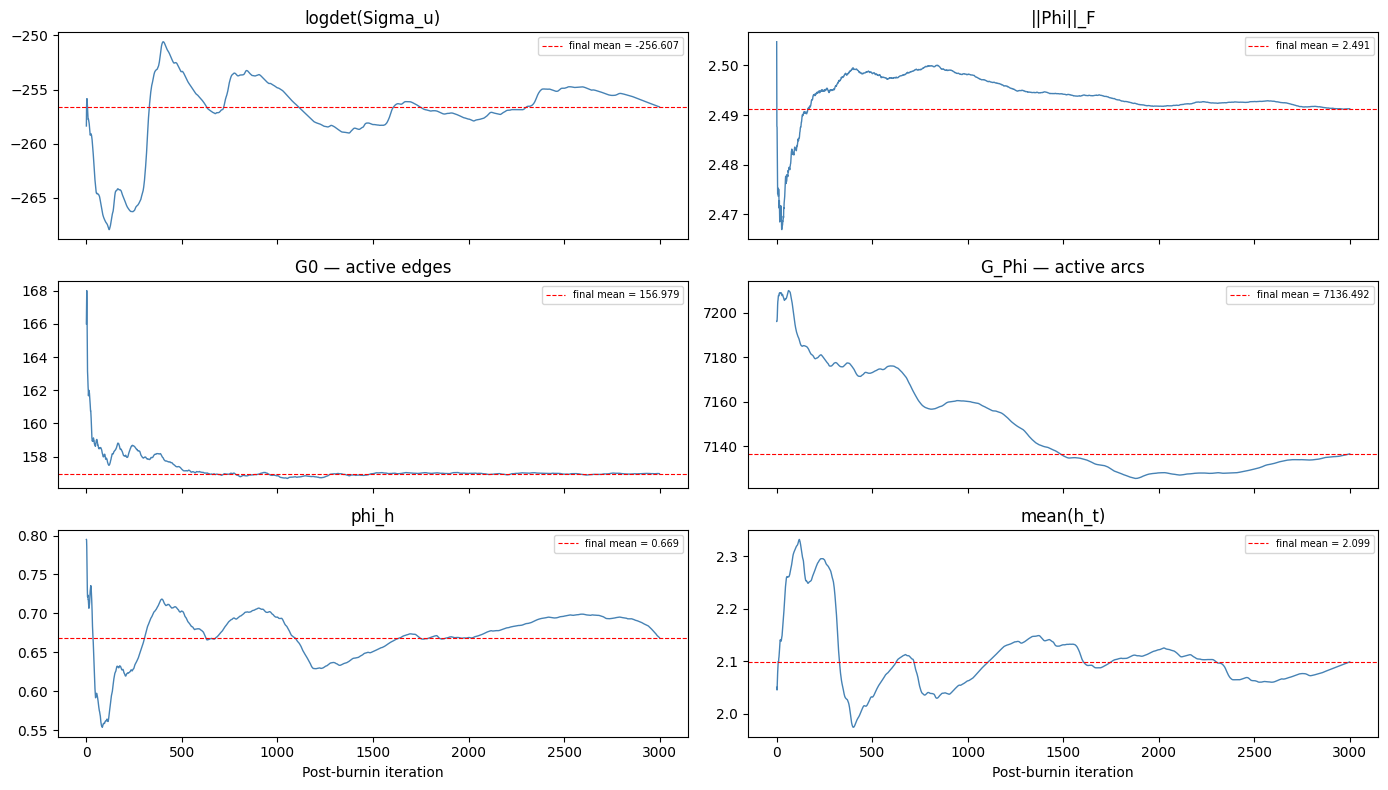

In [9]:
def running_mean(chain: np.ndarray) -> np.ndarray:
    return np.cumsum(chain) / np.arange(1, len(chain) + 1)

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
pairs = [
    ("logdet(Sigma_u)",  samples_all['logdet_Sigma']),
    ("||Phi||_F",        np.sqrt((samples_all['Phi'] ** 2).sum(axis=(0, 1, 2)))),
    ("G0 — active edges", samples_all['G0'].sum(axis=(0, 1)).astype(float)),
    ("G_Phi — active arcs", samples_all['G_Phi'].sum(axis=(0, 1, 2)).astype(float)),
    ("phi_h",            samples_all['phi_h']),
    ("mean(h_t)",        samples_all['h'].mean(axis=0)),
]

for ax, (name, ch) in zip(axes.flatten(), pairs):
    rm = running_mean(ch)
    ax.plot(rm, color="steelblue", lw=1.0)
    ax.axhline(ch.mean(), color="red", lw=0.8, linestyle="--",
               label=f"final mean = {ch.mean():.3f}")
    ax.set_title(name)
    ax.legend(fontsize=7)

axes[-1, 0].set_xlabel("Post-burnin iteration")
axes[-1, 1].set_xlabel("Post-burnin iteration")
plt.tight_layout()
plt.show()

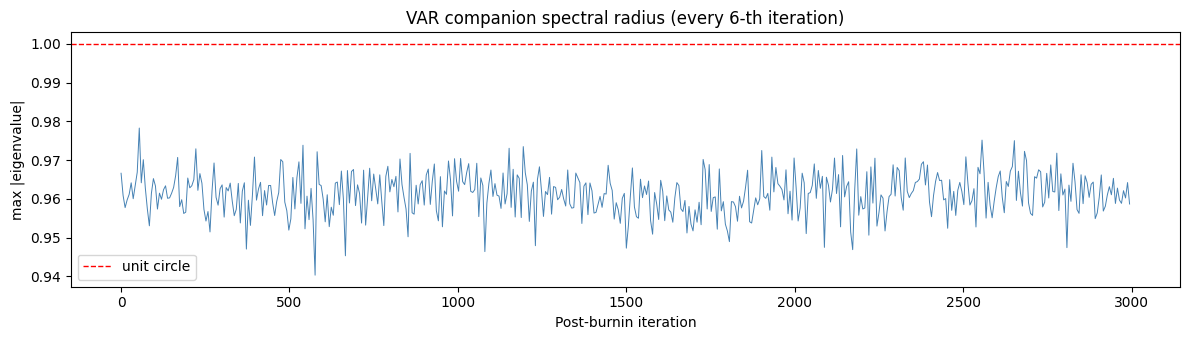

Spectral radius — mean=0.961  max=0.978  iterations >= 1.0: 0 / 500


In [10]:
def companion_spectral_radius(Phi_stack: np.ndarray) -> float:
    """
    Phi_stack: (ny, ny, n_lags) coefficient matrices for one iteration.
    Returns max |eigenvalue| of the VAR(p) companion matrix.
    """
    ny_, _, p = Phi_stack.shape
    top = np.hstack([Phi_stack[:, :, s] for s in range(p)])         # (ny, ny*p)
    eye = np.eye(ny_ * (p - 1)) if p > 1 else np.zeros((0, 0))
    zeros_right = np.zeros((ny_ * (p - 1), ny_)) if p > 1 else np.zeros((0, ny_))
    bottom = np.hstack([eye, zeros_right]) if p > 1 else np.zeros((0, ny_ * p))
    comp = np.vstack([top, bottom])
    eigs = np.linalg.eigvals(comp)
    return float(np.abs(eigs).max())

# Compute on a thinned subsample to save time (companion eigendecomp is O((ny*p)^3))
THIN = max(1, N_KEEP // 500)
radii = np.array([
    companion_spectral_radius(samples_all['Phi'][:, :, :, k])
    for k in range(0, N_KEEP, THIN)
])

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(np.arange(0, N_KEEP, THIN), radii, lw=0.7, color="steelblue")
ax.axhline(1.0, color="red", lw=1, linestyle="--", label="unit circle")
ax.set_xlabel("Post-burnin iteration")
ax.set_ylabel("max |eigenvalue|")
ax.set_title(f"VAR companion spectral radius (every {THIN}-th iteration)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Spectral radius — mean={radii.mean():.3f}  max={radii.max():.3f}  "
      f"iterations >= 1.0: {(radii >= 1.0).sum()} / {len(radii)}")

## Step 1 diagnostics : $G_0$

In [17]:
ny, _, N_KEEP = samples_all['G0'].shape
G0_expanded = np.load(OUTPUT_DIR / "G0_expanded.npy")

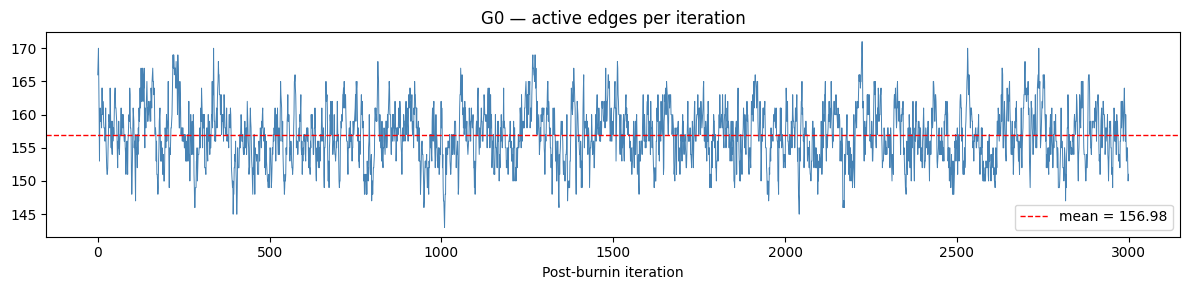

In [18]:
plot_trace(samples_all['G0'].sum(axis=(0,1)).astype(float), 
           "G0 — active edges per iteration")

In [ ]:
plot_acf_grid(samples_all['G0'], 
              G0_expanded, 
              "G0 — ACF per arc")

Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x0000018E40DF4860>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\_weakrefset.py", line 40, in _remove
    self = selfref()
           ^^^^^^^^^
KeyboardInterrupt: 


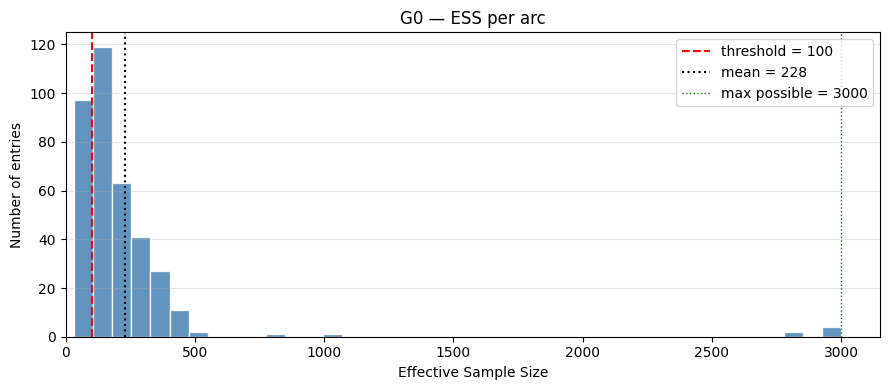

ESS summary — min=31  mean=228  median=148  max=3000  entries with ESS<100: 91/368 (24.7%)


In [36]:
plot_ess_histogram(samples_all['G0'], 
                 G0_expanded, 
                 "G0 — ESS per arc")

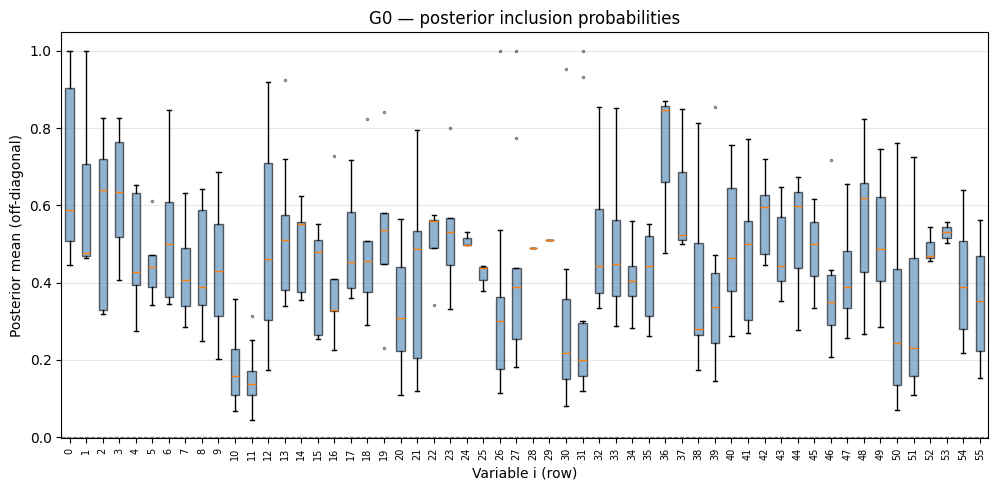

Top 5 variables with largest |median| off-diagonal posterior mean:
  variable  36  median|.|=0.8457  IQR=0.1965  max|.|=0.8703
  variable   2  median|.|=0.6390  IQR=0.3893  max|.|=0.8267
  variable   3  median|.|=0.6353  IQR=0.2453  max|.|=0.8257
  variable  48  median|.|=0.6187  IQR=0.2300  max|.|=0.8227
  variable  44  median|.|=0.5973  IQR=0.1978  max|.|=0.6727


In [40]:
plot_posterior_boxplot(samples_all['G0'], 
                       "G0 — posterior inclusion probabilities",
                       allowed_mask=G0_expanded)

## Step 2 diagnostics : $G_\Phi$

In [25]:
all_ones_mask = np.ones((ny, ny), dtype=int)

In [ ]:
# Per-lag breakdown on a single figure
fig, ax = plt.subplots(figsize=(12, 3))
for s in range(n_lags):
    series = samples_all['G_Phi'][:, :, s, :].sum(axis=(0,1))
    ax.plot(series, lw=0.7, label=f"lag index {s}")
ax.set_xlabel("Post-burnin iteration")
ax.set_title("G_Phi — active arcs per iteration, by lag")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
for s in range(n_lags):
    # Focus on arcs that were active at least once
    touched = (samples_all['G_Phi'][:, :, s, :].sum(axis=2) > 0).astype(int)
    if touched.sum() == 0:
        print(f"Lag index {s}: no arc was ever active — ACF skipped")
        continue
    plot_acf_grid(samples_all['G_phi'][:, :, s, :],
                  touched,
                  f"G_Phi — ACF per arc, lag index {s}")

In [ ]:
for s in range(n_lags):
    plot_ess_histogram(samples_all['G_Phi'][:, :, s, :],
                     all_ones_mask,
                     f"G_Phi — ESS per arc, lag index {s}")

In [ ]:
for s in range(n_lags):
    plot_posterior_boxplot(samples_all['G_Phi'][:, :, s, :],
                           f"G_Phi — inclusion probabilities, lag index {s}",
                           allowed_mask=all_ones_mask,
                           binary=True)

## Step 3 diagnostics : $\Sigma_u$

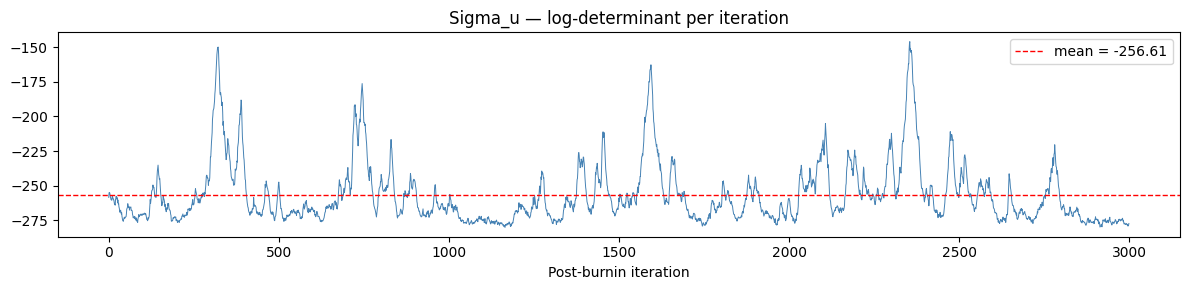

In [21]:
plot_trace(samples_all['logdet_Sigma'], "Sigma_u — log-determinant per iteration")

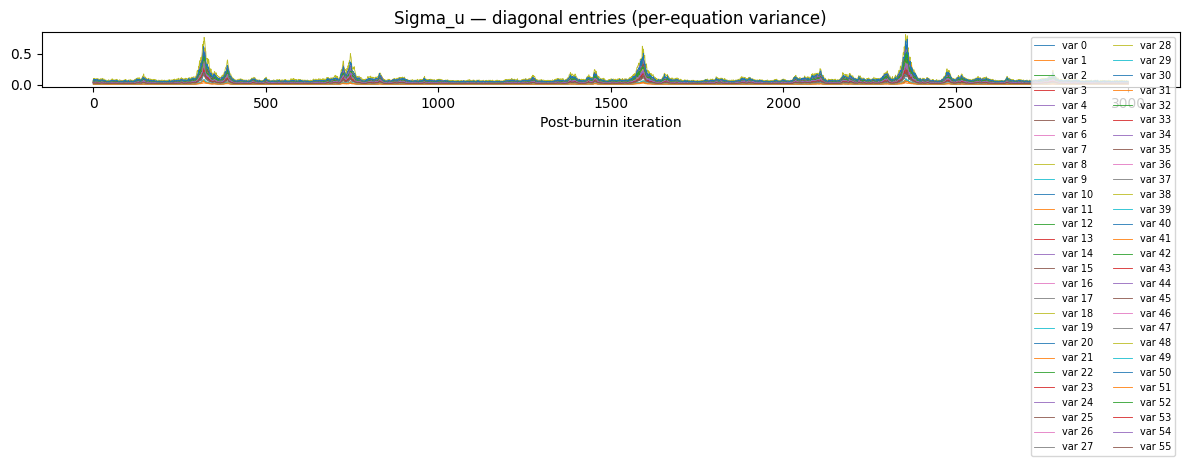

In [23]:
fig, ax = plt.subplots(figsize=(12, 3))
for i in range(ny):
    ax.plot(samples_all['Sigma_u'][i, i, :], lw=0.6, label=f"var {i}")
ax.set_xlabel("Post-burnin iteration")
ax.set_title("Sigma_u — diagonal entries (per-equation variance)")
ax.legend(loc="upper right", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

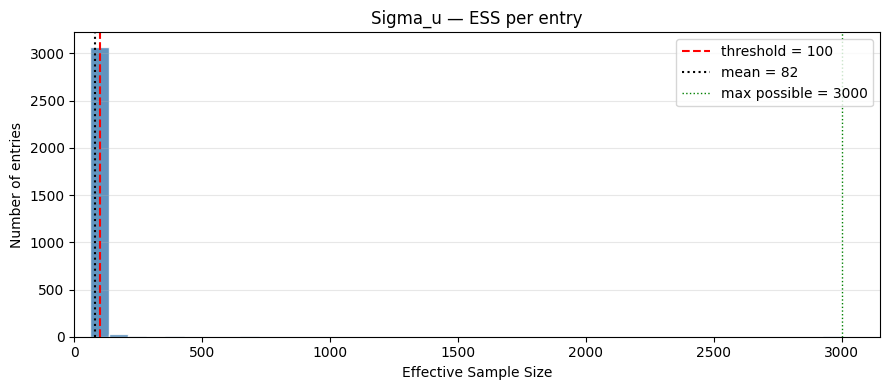

ESS summary — min=61  mean=82  median=69  max=3000  entries with ESS<100: 2990/3136 (95.3%)


In [37]:
plot_ess_histogram(samples_all['Sigma_u'], all_ones_mask, "Sigma_u — ESS per entry")

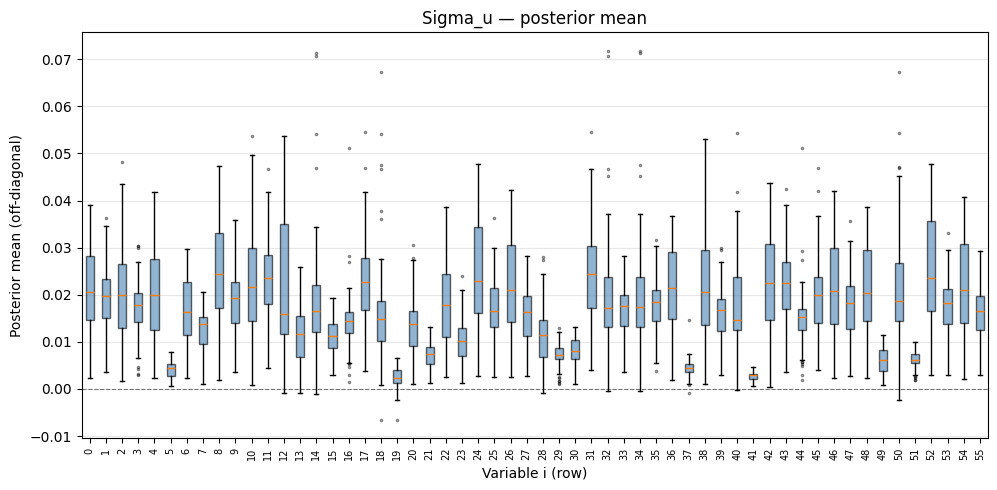

Top 5 variables with largest |median| off-diagonal posterior mean:
  variable   8  median|.|=0.0244  IQR=0.0160  max|.|=0.0474
  variable  31  median|.|=0.0243  IQR=0.0132  max|.|=0.0545
  variable  52  median|.|=0.0236  IQR=0.0192  max|.|=0.0478
  variable  11  median|.|=0.0236  IQR=0.0103  max|.|=0.0466
  variable  24  median|.|=0.0230  IQR=0.0183  max|.|=0.0478


In [42]:
plot_posterior_boxplot(samples_all['Sigma_u'],
                       "Sigma_u — posterior mean",
                       allowed_mask=all_ones_mask)

## Step 4 diagnostics : $\Phi$

In [ ]:
plot_trace(phi_norm_series, "Phi — Frobenius norm per iteration")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
for s in range(n_lags):
    series = (Phi_samples[:, :, s, :] ** 2).sum(axis=(0, 1))
    ax.plot(series, lw=0.7, label=f"lag index {s}")
ax.set_xlabel("Post-burnin iteration")
ax.set_ylabel("Sum of squared coefficients")
ax.set_title("Phi — squared magnitude per iteration, by lag")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
ACTIVE_THRESHOLD = 0.05   # arcs active in >= 5% of iterations

for s in range(n_lags):
    active_frac = samples_all['G_Phi'][:, :, s, :].mean(axis=2)
    mask = (active_frac >= ACTIVE_THRESHOLD).astype(int)
    if mask.sum() == 0:
        print(f"Lag index {s}: no arc above {ACTIVE_THRESHOLD:.0%} activity — ACF skipped")
        continue
    plot_acf_grid(Phi_samples[:, :, s, :],
                  mask,
                  f"Phi — ACF per coefficient, lag index {s} "
                  f"(arcs with >= {ACTIVE_THRESHOLD:.0%} activity)")

In [ ]:
for s in range(n_lags):
    plot_ess_histogram(Phi_samples[:, :, s, :],
                     all_ones_mask,
                     f"Phi — ESS per coefficient, lag index {s}")

In [ ]:
for s in range(n_lags):
    plot_posterior_boxplot(Phi_samples[:, :, s, :],
                           f"Phi — marginal posterior mean, lag index {s}",
                           allowed_mask=all_ones_mask,
                           binary=False)

### Inclusion probability vs |coefficient|

Scatter of posterior inclusion probability against the absolute value of the conditional posterior mean across all (i, j, s).

This diagnostics shows if the graph selection and the shrinkage are working coherently. 

In [ ]:
incl_prob = samples_all['G_Phi'].mean(axis=3)                             # (ny, ny, n_lags)

active_all   = (samples_all['G_Phi'] == 1)
n_active_all = active_all.sum(axis=3)
phi_sum_all  = np.where(active_all, Phi_samples, 0.0).sum(axis=3)
with np.errstate(invalid='ignore', divide='ignore'):
    cond_mean_all = np.where(n_active_all > 0, phi_sum_all / n_active_all, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
for s in range(n_lags):
    x = incl_prob[:, :, s].ravel()
    y = np.abs(cond_mean_all[:, :, s]).ravel()
    mask = ~np.isnan(y)
    ax.scatter(x[mask], y[mask], s=18, alpha=0.6, label=f"lag index {s}")
ax.set_xlabel("Posterior inclusion probability")
ax.set_ylabel("|Conditional posterior mean|")
ax.set_title("Phi — inclusion probability vs |coefficient|")
ax.legend(fontsize=8)
ax.set_xlim(-0.02, 1.02)
plt.tight_layout()
plt.show()

## Step 5 diagnostics

## Step 6 diagnostics $h_t$ e $\lambda_t$

In [ ]:
plot_trace(mu_h_samples,     "mu_h — AR(1) long-run mean of log-volatility")
plot_trace(phi_h_samples,    "phi_h — AR(1) persistence of log-volatility")
plot_trace(sigma_h2_samples, "sigma_h2 — variance of log-volatility innovations")

In [ ]:
def _ess_1d(chain: np.ndarray, max_lags: int = 100) -> float:
    n = len(chain)
    if chain.std() == 0:
        return float(n)
    acf_vals = acf(chain.astype(float), nlags=max_lags, fft=True)
    rho_sum = 0.0
    for k in range(1, len(acf_vals)):
        if acf_vals[k] < 0:
            break
        rho_sum += acf_vals[k]
    return n / (1 + 2 * rho_sum)

ess_h   = np.array([_ess_1d(h_samples[t, :])      for t in range(T)])
ess_lam = np.array([_ess_1d(lambda_samples[t, :]) for t in range(T)])

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(ess_h, color="steelblue", lw=0.8)
axes[0].axhline(N_KEEP, color="green", lw=0.8, linestyle=":", label=f"N_KEEP = {N_KEEP}")
axes[0].axhline(100,    color="red",   lw=0.8, linestyle="--", label="ESS = 100")
axes[0].set_ylabel("ESS(h_t)")
axes[0].set_title("Effective sample size per time point")
axes[0].legend(fontsize=8)

axes[1].plot(ess_lam, color="seagreen", lw=0.8)
axes[1].axhline(N_KEEP, color="green", lw=0.8, linestyle=":")
axes[1].axhline(100,    color="red",   lw=0.8, linestyle="--")
axes[1].set_xlabel("Time t")
axes[1].set_ylabel("ESS(lambda_t)")

plt.tight_layout()
plt.show()

print(f"h_t       — ESS: min={ess_h.min():.0f}  mean={ess_h.mean():.0f}  "
      f"max={ess_h.max():.0f}  points with ESS<100: {(ess_h < 100).sum()}/{T}")
print(f"lambda_t  — ESS: min={ess_lam.min():.0f}  mean={ess_lam.mean():.0f}  "
      f"max={ess_lam.max():.0f}  points with ESS<100: {(ess_lam < 100).sum()}/{T}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

for ax, samples, name in zip(
    axes,
    [mu_h_samples, phi_h_samples, sigma_h2_samples],
    ["mu_h", "phi_h", "sigma_h2"],
):
    acf_vals = acf(samples, nlags=40, fft=True)
    ax.bar(range(len(acf_vals)), acf_vals, width=0.8, color="steelblue")
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline( 1.96 / np.sqrt(N_KEEP), color="red", lw=0.8, linestyle="--")
    ax.axhline(-1.96 / np.sqrt(N_KEEP), color="red", lw=0.8, linestyle="--")
    ax.set_title(f"{name} — ACF")
    ax.set_ylim(-0.3, 1.05)

plt.tight_layout()
plt.show()

print(f"ESS(mu_h)     = {_ess_1d(mu_h_samples):.0f}")
print(f"ESS(phi_h)    = {_ess_1d(phi_h_samples):.0f}")
print(f"ESS(sigma_h2) = {_ess_1d(sigma_h2_samples):.0f}")

### Marginal posteriors of hyperparameters
- `phi_h` close to 1 means highly persistent volatility (typical for financial/macro data).
- `sigma_h2` controls how jumpy the volatility path is.
- `mu_h` pins down the average level of log-variance.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, samples, name in zip(
    axes,
    [mu_h_samples, phi_h_samples, sigma_h2_samples],
    ["mu_h", "phi_h", "sigma_h2"],
):
    ax.hist(samples, bins=40, color="steelblue", edgecolor="white")
    ax.axvline(samples.mean(), color="red", lw=1.2, linestyle="--",
               label=f"mean = {samples.mean():.3f}")
    ax.set_title(f"{name} — posterior distribution")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Log-volatility path $h_t$
The posterior mean of `h_t` plotted with 90% credible bands.
Peaks correspond to high-volatility periods; valleys to calm periods.

In [ ]:
h_mean = h_samples.mean(axis=1)
h_lo   = np.quantile(h_samples, 0.05, axis=1)
h_hi   = np.quantile(h_samples, 0.95, axis=1)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(np.arange(T), h_lo, h_hi, color="steelblue", alpha=0.25,
                label="90% credible band")
ax.plot(h_mean, color="steelblue", lw=1.2, label="posterior mean")
ax.axhline(0, color="black", lw=0.5, linestyle=":")
ax.set_xlabel("Time t")
ax.set_ylabel("h_t (log-variance)")
ax.set_title("Stochastic volatility — posterior path of h_t")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Implied volatility path: sqrt(exp(h_t))
vol_mean = np.exp(0.5 * h_samples).mean(axis=1)
vol_lo   = np.quantile(np.exp(0.5 * h_samples), 0.05, axis=1)
vol_hi   = np.quantile(np.exp(0.5 * h_samples), 0.95, axis=1)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(np.arange(T), vol_lo, vol_hi, color="darkorange", alpha=0.25,
                label="90% credible band")
ax.plot(vol_mean, color="darkorange", lw=1.2, label="posterior mean")
ax.set_xlabel("Time t")
ax.set_ylabel("sqrt(exp(h_t))  —  volatility scaling factor")
ax.set_title("Implied volatility scaling over time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()